# Failure of Crowded Technical Signals
## Research Question: Do crowded technical signals fail to follow through?

**Thesis (Barber & Odean, 2008 / Da et al., 2011):**  
When a technical alert is widely noticed and acted upon — high volume, extreme price position, 
multiple concurrent signals — it tends to *fail to follow through*. Retail attention creates 
temporary momentum that reverses once the crowd is fully positioned.

**We test:** 
1. Do signals fail more than 50% of the time? (baseline analysis)
2. Does crowding increase failure probability? (core hypothesis)  
3. Can we predict failure reliably enough to trade? (model evaluation)
4. What is the profit from fading high-failure signals? (agent application)

**Universe:** EURO STOXX 50 stocks | **Horizon:** 1–5 trading days | **Data:** 7 years

In [1]:
import sys, warnings, json, yaml
from pathlib import Path
from datetime import datetime, timedelta

ROOT      = Path('..').resolve()
AGENT     = ROOT / 'trading_agent'
MODEL_DIR = AGENT / 'data' / 'model'
CACHE_DIR = AGENT / 'data' / 'cache'
NB_CACHE  = ROOT / 'data' / 'features'
NB_CACHE.mkdir(parents=True, exist_ok=True)

for p in [str(ROOT), str(AGENT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import yfinance as yf
from sklearn.metrics import roc_auc_score, precision_recall_curve, precision_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (14, 5),
                     'axes.spines.top': False, 'axes.spines.right': False})

with open(AGENT / 'configs' / 'config.yaml') as f:
    cfg = yaml.safe_load(f)

# Variants limited to those with trained models and available data horizons
VARIANTS = [
    ('h1d_longonly',  1,  'longonly'),
    ('h3d_longonly',  3,  'longonly'),
    ('h5d_longonly',  5,  'longonly'),
    ('h1d_both',      1,  'both'),
    ('h3d_both',      3,  'both'),
    ('h5d_both',      5,  'both'),
]
HORIZONS    = [1, 3, 5]
COMMISSION  = 0.002   # 0.2% round-trip

# Use the best available trained model as ACTIVE
cfg_active = cfg['model'].get('variant', 'h5d_longonly')
available = [v for v, _, _ in VARIANTS if (MODEL_DIR / f'xgboost_{v}.joblib').exists()]
ACTIVE = cfg_active if cfg_active in available else (available[0] if available else 'h5d_longonly')

print(f'Active variant : {ACTIVE}')
print(f'Trained models : {available or "NONE — run: python bootstrap_model.py --yfinance"}')

Active variant : h1d_longonly
Trained models : ['h1d_longonly', 'h3d_longonly', 'h5d_longonly', 'h1d_both', 'h3d_both', 'h5d_both']


In [2]:
"""Build feature + label pipeline. Uses cached files if available."""
REBUILD    = False
NB_LABELED = NB_CACHE / 'events_labeled_nb.parquet'
NB_FEATS   = NB_CACHE / 'feat_panel_nb.parquet'

if not REBUILD and NB_LABELED.exists() and NB_FEATS.exists():
    print('Loading cached pipeline...')
    labeled    = pd.read_parquet(NB_LABELED)
    feat_panel = pd.read_parquet(NB_FEATS)
else:
    print('Building pipeline from cache...')
    from src.data.preprocess import build_panel
    from src.features.engineering import build_features, add_alert_features
    from src.features.labels import compute_forward_returns, assign_labels
    from src.alerts.engine import run_alert_engine

    _hist_days  = cfg['data'].get('history_days', 2555)
    _hist_start = (datetime.now() - timedelta(days=_hist_days + 10)).strftime('%Y-%m-%d')

    raw_dict = {}
    with open(ROOT / 'configs' / 'eurostoxx50_tickers.yaml') as f:
        tickers_list = yaml.safe_load(f)['tickers']

    for ticker in tickers_list:
        cache_file = CACHE_DIR / f"{ticker.replace('/', '_')}.parquet"
        if not cache_file.exists():
            continue
        df = pd.read_parquet(cache_file)
        d  = df.rename(columns={'open':'Open','high':'High','low':'Low',
                                'close':'Close','volume':'Volume'}).copy()
        d.index   = pd.to_datetime(d['date'] if 'date' in d.columns else d.index)
        d['ticker'] = ticker
        raw_dict[ticker] = d

    try:
        idx = yf.download('^STOXX50E', start=_hist_start, auto_adjust=True, progress=False)
        idx.columns = [c[0] if isinstance(c, tuple) else c for c in idx.columns]
        index_close = idx['Close'].copy()
        index_close.index = pd.to_datetime(index_close.index)
    except Exception:
        index_close = None
        print('Could not fetch index — regime features disabled')

    panel      = build_panel(raw_dict, min_history_days=cfg['model']['min_history_days'])
    feat_panel = build_features(panel, index_close=index_close)
    feat_panel = compute_forward_returns(feat_panel, horizons=HORIZONS)
    events     = run_alert_engine(panel)
    events     = add_alert_features(events, panel)
    labeled    = assign_labels(events, feat_panel, horizons=HORIZONS, theta=0.005)
    feat_panel.to_parquet(NB_FEATS, index=False)
    labeled.to_parquet(NB_LABELED, index=False)
    print(f'Pipeline built and cached to {NB_CACHE}')

labeled['date'] = pd.to_datetime(labeled['date'])
labeled = labeled.sort_values('date').reset_index(drop=True)
feat_panel['date'] = pd.to_datetime(feat_panel['date'])

# Detect available horizons from data
HORIZONS = [h for h in [1, 3, 5, 10] if f'label_failure_{h}d' in labeled.columns]

print(f'Events: {len(labeled):,}  |  Tickers: {labeled["ticker"].nunique()}  |  '
      f'Date range: {labeled["date"].min().date()} - {labeled["date"].max().date()}')
for h in HORIZONS:
    col = f'label_failure_{h}d'
    print(f'  h={h}d  base failure rate: {labeled[col].mean():.1%}  '
          f'({"above" if labeled[col].mean() > 0.5 else "below"} 50%)')

Loading cached pipeline...
Events: 81,375  |  Tickers: 49  |  Date range: 2019-03-12 - 2026-03-17
  h=1d  base failure rate: 38.1%  (below 50%)
  h=3d  base failure rate: 44.6%  (below 50%)
  h=5d  base failure rate: 45.8%  (below 50%)


---
## 1. Do Technical Signals Fail to Follow Through?

**Failure** = price moves against the alert direction within N days (after commission).  
A failure rate above 50% means the alert is a *contrarian* indicator on average.  
We need sustained failure rates to justify a fade strategy.

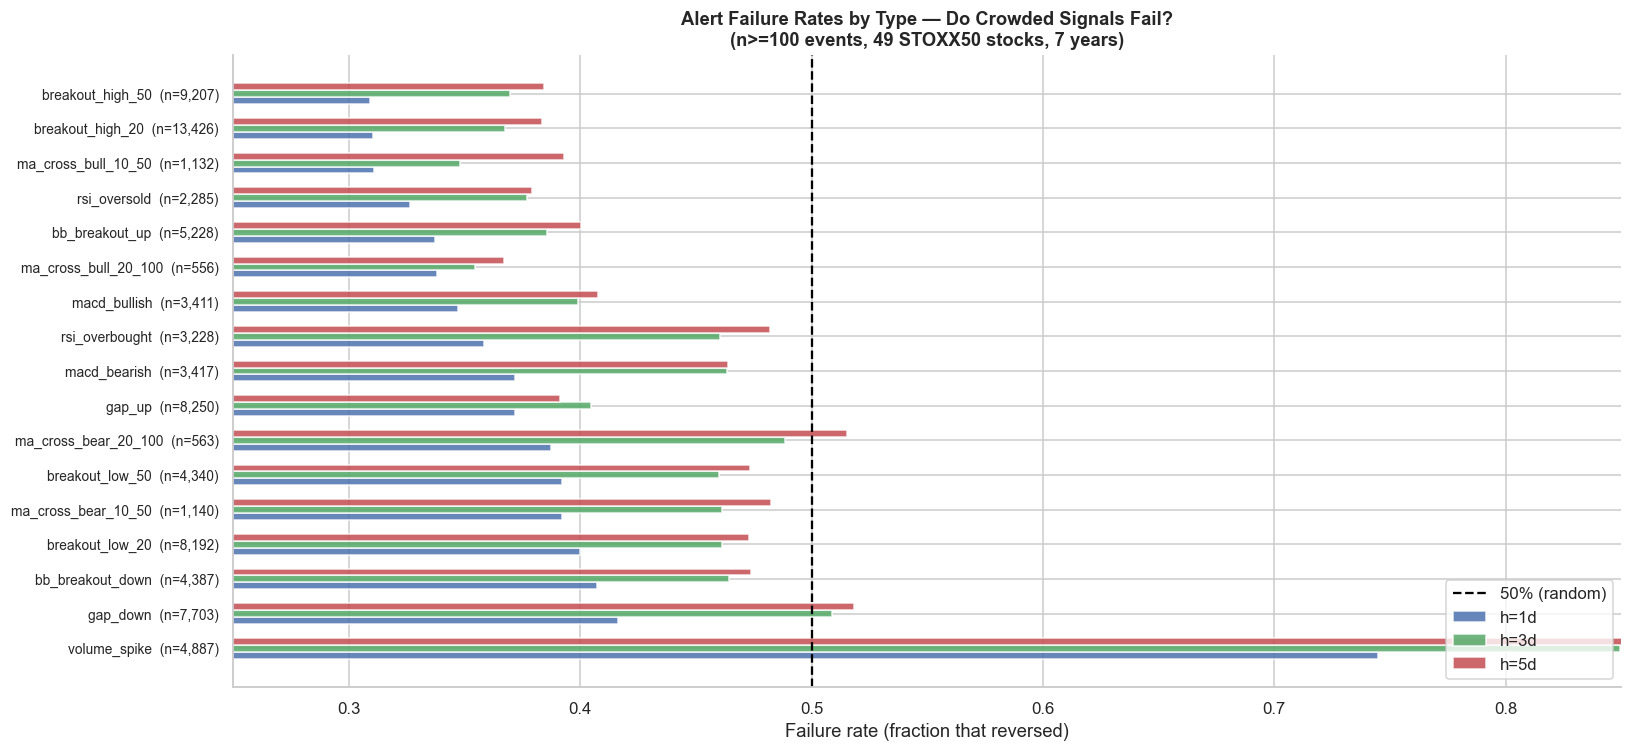


Alert failure rates (h=1d, sorted descending):
                      h=1d  h=3d  h=5d
alert_name                            
volume_spike         74.5% 85.0% 88.5%
gap_down             41.6% 50.9% 51.8%
bb_breakout_down     40.7% 46.4% 47.4%
breakout_low_20      40.0% 46.1% 47.3%
ma_cross_bear_10_50  39.2% 46.1% 48.2%
breakout_low_50      39.2% 46.0% 47.4%
ma_cross_bear_20_100 38.7% 48.8% 51.5%
gap_up               37.2% 40.5% 39.1%
macd_bearish         37.2% 46.3% 46.4%
rsi_overbought       35.8% 46.0% 48.2%
macd_bullish         34.7% 39.9% 40.8%
ma_cross_bull_20_100 33.8% 35.4% 36.7%
bb_breakout_up       33.7% 38.6% 40.0%
rsi_oversold         32.6% 37.7% 37.9%
ma_cross_bull_10_50  31.1% 34.8% 39.3%
breakout_high_20     31.0% 36.7% 38.4%
breakout_high_50     30.9% 37.0% 38.4%

Key finding: failure rates > 50% indicate systematic reversal tendency (fade-worthy).


In [3]:
# Failure rate by alert type and horizon
MIN_EVENTS = 100
cnt = labeled['alert_name'].value_counts()
reliable = cnt[cnt >= MIN_EVENTS].index

fail_cols = {h: f'label_failure_{h}d' for h in HORIZONS if f'label_failure_{h}d' in labeled.columns}

fail_df = (
    labeled[labeled['alert_name'].isin(reliable)]
    .groupby('alert_name')[list(fail_cols.values())]
    .mean()
    .rename(columns={v: f'h={k}d' for k,v in fail_cols.items()})
    .join(cnt.rename('n_events'))
    .sort_values(f'h={HORIZONS[0]}d', ascending=False)
)

palette = ['#4C72B0','#55A868','#C44E52','#DD8452']
h_cols = [c for c in fail_df.columns if c.startswith('h=')]

fig, ax = plt.subplots(figsize=(15, 7))
x = np.arange(len(fail_df))
w = 0.20
for i, col in enumerate(h_cols):
    ax.barh(x - w*(len(h_cols)/2 - 0.5 - i), fail_df[col], w, label=col,
            color=palette[i % len(palette)], alpha=0.85)

ax.axvline(0.50, color='black', linestyle='--', linewidth=1.5, label='50% (random)')
ax.set_yticks(x)
ax.set_yticklabels([f"{a}  (n={fail_df.loc[a,'n_events']:,})" for a in fail_df.index], fontsize=9)
ax.set_xlabel('Failure rate (fraction that reversed)')
ax.set_title('Alert Failure Rates by Type — Do Crowded Signals Fail?\n'
             f'(n>={MIN_EVENTS} events, {labeled["ticker"].nunique()} STOXX50 stocks, 7 years)',
             fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0.25, 0.85)
plt.tight_layout()
plt.show()

first_h_col = h_cols[0]
print(f'\nAlert failure rates ({first_h_col}, sorted descending):')
print(fail_df[h_cols].sort_values(first_h_col, ascending=False)
      .to_string(float_format='{:.1%}'.format))
print('\nKey finding: failure rates > 50% indicate systematic reversal tendency (fade-worthy).')

---
## 2. Does Crowding Increase Failure Probability?

This is the **core hypothesis** (Barber & Odean, 2008):  
High-attention events (volume surge, extreme price, multiple alerts) fail MORE.

We split events into crowding quintiles and compare failure rates.  
If the thesis is correct: **high crowding → higher failure rate**.

Crowding scores computed. Mean=0.409  Median=0.400  High (>=0.3): 77.3%


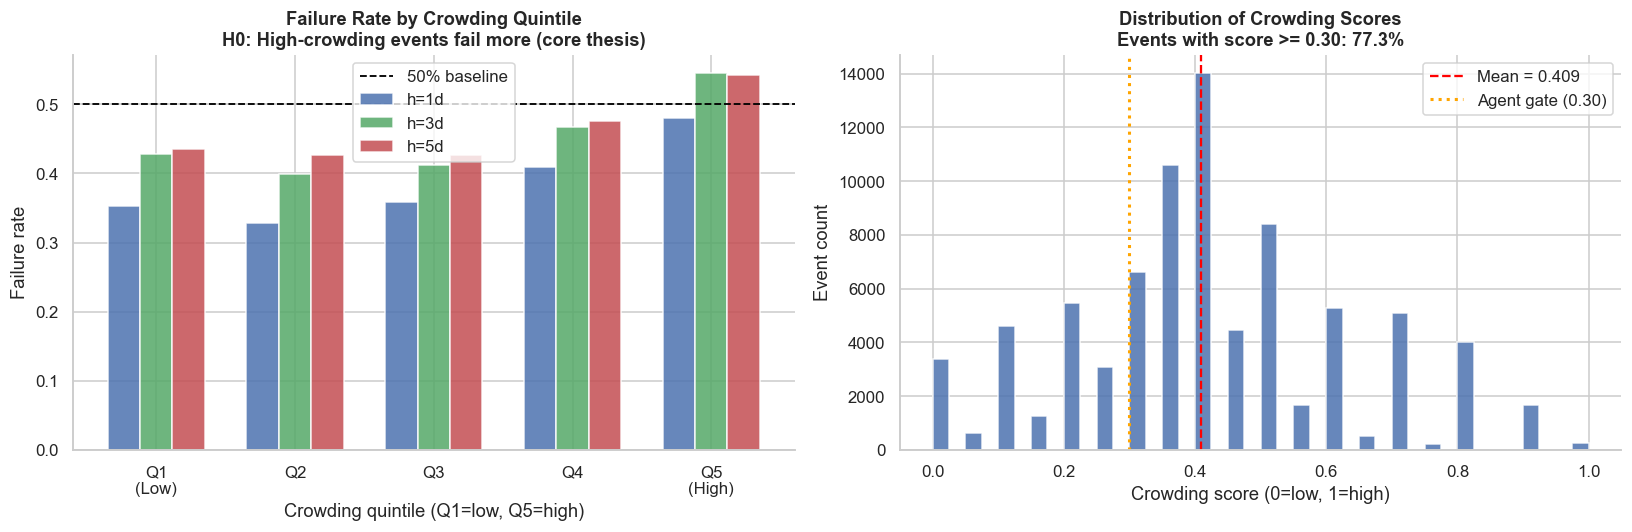


Correlation: crowding score vs failure rate
  Crowding <-> failure h=1d:  Pearson r = +0.0875  (thesis SUPPORTED)
  Crowding <-> failure h=3d:  Pearson r = +0.0757  (thesis SUPPORTED)
  Crowding <-> failure h=5d:  Pearson r = +0.0650  (thesis SUPPORTED)


In [4]:
# Compute crowding scores for all events using the explain module
sys.path.insert(0, str(AGENT))
from agent.explain import compute_crowding_score

# Build crowding scores by joining feat_panel features to labeled events
# n_simultaneous_alerts lives in labeled; vol/price/atr features in feat_panel
feat_lookup = feat_panel.set_index(['date', 'ticker'])

crowding_scores = []
for _, row in labeled.iterrows():
    key = (row['date'], row['ticker'])
    # Start with the labeled row fields (includes n_simultaneous_alerts)
    combined = row.copy()
    if key in feat_lookup.index:
        feat_row = feat_lookup.loc[key]
        if isinstance(feat_row, pd.DataFrame):
            feat_row = feat_row.iloc[0]
        combined = pd.concat([combined, feat_row[feat_row.index.difference(combined.index)]])
    crowding_scores.append(compute_crowding_score(combined))

labeled['crowding_score'] = crowding_scores
print(f'Crowding scores computed. Mean={np.mean(crowding_scores):.3f}  '
      f'Median={np.median(crowding_scores):.3f}  '
      f'High (>=0.3): {(np.array(crowding_scores)>=0.3).mean():.1%}')

# Split into quintiles
labeled['crowding_q'] = pd.qcut(labeled['crowding_score'], q=5,
                                  labels=['Q1\n(Low)', 'Q2', 'Q3', 'Q4', 'Q5\n(High)'],
                                  duplicates='drop')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Failure rate by crowding quintile
fail_label_cols = [f'label_failure_{h}d' for h in HORIZONS if f'label_failure_{h}d' in labeled.columns]
q_fail = labeled.groupby('crowding_q')[fail_label_cols].mean()
q_fail.columns = [f'h={h}d' for h in HORIZONS if f'label_failure_{h}d' in labeled.columns]
q_fail.plot.bar(ax=axes[0], color=palette[:len(q_fail.columns)], alpha=0.85, width=0.7)
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=1.2, label='50% baseline')
axes[0].set_title('Failure Rate by Crowding Quintile\n'
                   'H0: High-crowding events fail more (core thesis)', fontweight='bold')
axes[0].set_xlabel('Crowding quintile (Q1=low, Q5=high)')
axes[0].set_ylabel('Failure rate')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=0)

# Distribution of crowding scores
axes[1].hist(labeled['crowding_score'], bins=40, color='#4C72B0', alpha=0.85, edgecolor='white')
axes[1].axvline(labeled['crowding_score'].mean(), color='red', linestyle='--',
                 label=f'Mean = {labeled["crowding_score"].mean():.3f}')
axes[1].axvline(0.30, color='orange', linestyle=':', linewidth=2,
                 label='Agent gate (0.30)')
axes[1].set_title('Distribution of Crowding Scores\n'
                   f'Events with score >= 0.30: {(labeled["crowding_score"]>=0.30).mean():.1%}',
                   fontweight='bold')
axes[1].set_xlabel('Crowding score (0=low, 1=high)')
axes[1].set_ylabel('Event count')
axes[1].legend()

plt.tight_layout()
plt.show()

# Correlation between crowding and failure
print('\nCorrelation: crowding score vs failure rate')
for h in HORIZONS:
    col = f'label_failure_{h}d'
    if col in labeled.columns:
        corr = labeled[['crowding_score', col]].dropna().corr().iloc[0, 1]
        verdict = 'thesis SUPPORTED' if corr > 0 else 'thesis NOT supported'
        print(f'  Crowding <-> failure h={h}d:  Pearson r = {corr:+.4f}  ({verdict})')

---
## 3. Can We Predict Alert Failure Reliably?

For a fade strategy to work profitably, the model must:
- **Discriminate** well (AUC > 0.5)  
- **Calibrate** correctly (P=0.65 => ~65% actually fail)
- **Achieve precision** above break-even at the trading threshold

Break-even precision: SL=1.5%, TP=2.5%, commission=0.2% => need >40% precision (reward/risk = 1.67:1).  
For h5d: SL=3.5%, TP=6% => break-even ~37%.

In [5]:
def _build_eval_matrix(labeled, feat_panel, horizon, mode):
    """Build (X, y, dates) for evaluation. Labels are always failure labels."""
    EXCLUDE = {'date','ticker','open','high','low','close','volume',
               'ret_1d_lead','alert_name','direction','n_simultaneous_alerts','_dir_raw',
               'crowding_score','crowding_q'}
    EXCLUDE |= {c for c in labeled.columns if c.startswith(('fwd_ret_','label_'))}

    feat_cols_all = [c for c in feat_panel.columns if c not in EXCLUDE]
    pf = feat_panel[['date','ticker'] + feat_cols_all].copy()
    pf['date'] = pd.to_datetime(pf['date'])

    lab = labeled.copy()
    lab['date'] = pd.to_datetime(lab['date'])
    if mode == 'longonly':
        lab = lab[lab['direction'].isin(['bearish','neutral'])].copy()

    label_col = f'label_failure_{horizon}d'
    if label_col not in lab.columns:
        return None, None, None, None

    lab['_dir_raw'] = lab['direction']
    lab = pd.get_dummies(lab, columns=['direction','alert_name'], drop_first=False)
    merged = lab.merge(pf.drop_duplicates(['date','ticker']), on=['date','ticker'], how='left')
    merged = merged.sort_values('date').reset_index(drop=True)

    onehot   = [c for c in merged.columns if c.startswith(('direction_','alert_name_'))]
    pfcols   = [c for c in merged.columns if c in feat_cols_all]
    extra    = [c for c in ['n_simultaneous_alerts'] if c in merged.columns]
    fcols    = list(dict.fromkeys(pfcols + onehot + extra))
    fcols    = [c for c in fcols if c in merged.columns and merged[c].dtype != object]

    valid = merged[label_col].notna()
    X     = merged.loc[valid, fcols].fillna(-1)
    y     = merged.loc[valid, label_col]
    dates = merged.loc[valid, 'date']
    return X, y, dates, fcols


THRESHOLDS = [0.50, 0.55, 0.60, 0.65, 0.70]
eval_results = {}

for vname, horizon, mode in VARIANTS:
    mp = MODEL_DIR / f'xgboost_{vname}.joblib'
    cp = MODEL_DIR / f'feature_cols_{vname}.json'
    if not mp.exists():
        print(f'  [skip] {vname} — not trained')
        continue
    if not cp.exists():
        print(f'  [skip] {vname} — feature_cols file missing')
        continue
    model = joblib.load(mp)
    with open(cp) as f:
        feat_cols_trained = json.load(f)

    X, y, dates, _ = _build_eval_matrix(labeled, feat_panel, horizon, mode)
    if X is None:
        print(f'  [skip] {vname} — label missing')
        continue

    common = [c for c in feat_cols_trained if c in X.columns]
    if not common:
        print(f'  [skip] {vname} — no matching feature columns')
        continue
    X = X[common].fillna(-1)
    split = int(len(X) * 0.80)
    X_v, y_v, d_v = X.iloc[split:], y.iloc[split:], dates.iloc[split:]
    if len(y_v) < 50 or y_v.nunique() < 2:
        print(f'  [skip] {vname} — too few validation samples ({len(y_v)})')
        continue

    probas = model.predict_proba(X_v)[:, 1]
    auc    = roc_auc_score(y_v, probas)
    thr_stats = {}
    for t in THRESHOLDS:
        pred = (probas >= t).astype(int)
        n    = int(pred.sum())
        prec = float(precision_score(y_v, pred, zero_division=0)) if n > 5 else float('nan')
        thr_stats[t] = {'n': n, 'prec': prec}

    eval_results[vname] = {
        'horizon': horizon, 'mode': mode,
        'n_val': len(y_v), 'failure_rate': float(y_v.mean()),
        'auc': auc, 'probas': probas, 'y_val': y_v.values,
        'dates_val': d_v, 'thr': thr_stats,
        'importance': dict(zip(common, model.feature_importances_)),
    }
    active_mark = '  <- ACTIVE' if vname == ACTIVE else ''
    print(f'  {vname:<18}  AUC={auc:.4f}  fail%={y_v.mean():.1%}  n={len(y_v):,}{active_mark}')

print(f'\n{len(eval_results)}/{len(VARIANTS)} variants evaluated.')

  h1d_longonly        AUC=0.6291  fail%=42.8%  n=7,576  <- ACTIVE


  h3d_longonly        AUC=0.5846  fail%=49.3%  n=7,576


  h5d_longonly        AUC=0.5974  fail%=52.0%  n=7,576


  h1d_both            AUC=0.6049  fail%=36.7%  n=16,275


  h3d_both            AUC=0.5934  fail%=43.5%  n=16,275


  h5d_both            AUC=0.5855  fail%=45.4%  n=16,275

6/6 variants evaluated.


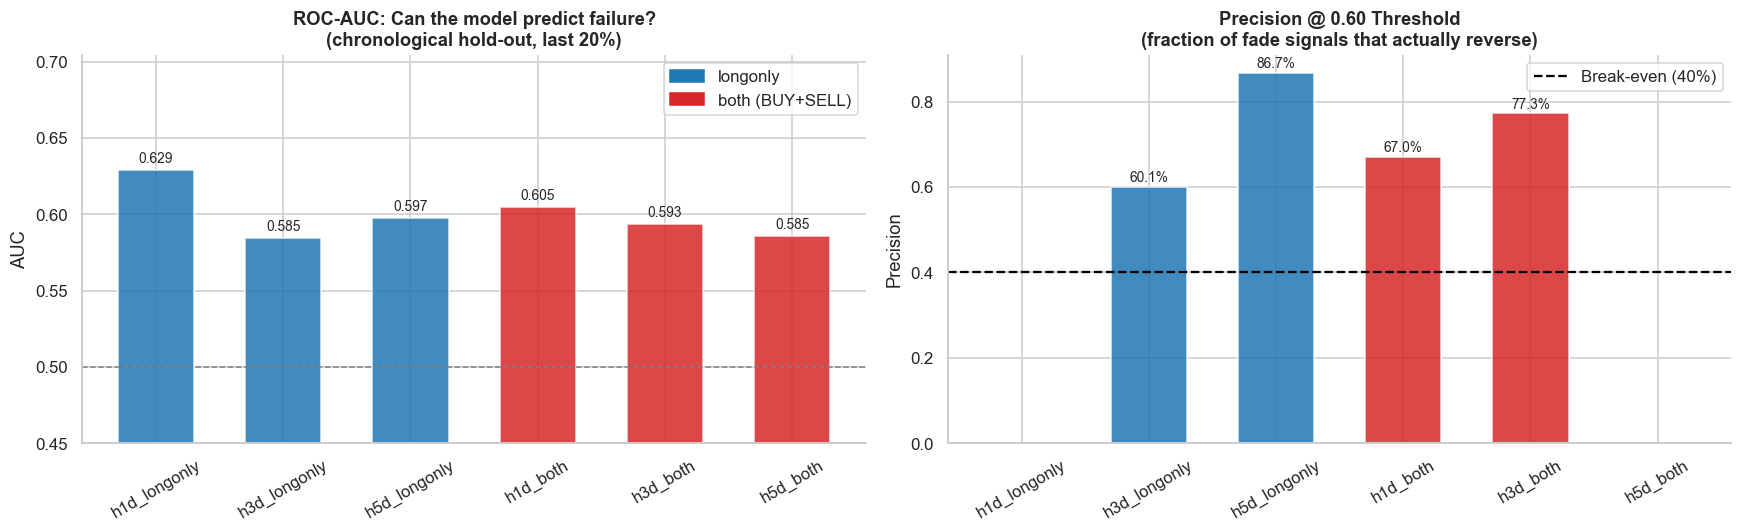


Precision @ threshold (break-even = 40%)  — * = above break-even
 Variant                 AUC   fail%  P@0.5  P@0.55  P@0.6  P@0.65  P@0.7
----------------------------------------------------------------------------------------------------
  h1d_longonly        0.6291   42.8%  75.3%*(n=761)    n/a            n/a            n/a            n/a            <- ACTIVE
  h3d_longonly        0.5846   49.3%  56.1%*(n=3,286)  57.1%*(n=2,539)  60.1%*(n=2,009)  68.4%*(n=1,520)  73.0%*(n=1,224)  
  h5d_longonly        0.5974   52.0%  61.9%*(n=2,401)  72.2%*(n=1,454)  86.7%*(n=1,008)  89.7%*(n=358)    n/a          
  h1d_both            0.6049   36.7%  47.5%*(n=4,930)  60.9%*(n=1,689)  67.0%*(n=1,350)  69.0%*(n=1,065)  74.3%*(n=814)  
  h3d_both            0.5934   43.5%  55.5%*(n=3,468)  61.2%*(n=2,139)  77.3%*(n=1,218)  82.0%*(n=812)  80.0%*(n=130)  
  h5d_both            0.5855   45.4%  56.2%*(n=4,409)  85.9%*(n=1,001)    n/a            n/a            n/a          


In [6]:
if eval_results:
    BREAKEVEN = 0.40  # min precision for positive EV (SL=1.5%, TP=2.5%)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    vnames = list(eval_results.keys())
    aucs   = [eval_results[v]['auc'] for v in vnames]
    cols   = ['#1f77b4' if 'longonly' in v else '#d62728' for v in vnames]
    bars   = axes[0].bar(vnames, aucs, color=cols, alpha=0.85, width=0.6)
    axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random (0.5)')
    axes[0].set_ylim(0.45, max(aucs)*1.12)
    axes[0].set_title('ROC-AUC: Can the model predict failure?\n'
                       '(chronological hold-out, last 20%)', fontweight='bold')
    axes[0].set_ylabel('AUC')
    axes[0].tick_params(axis='x', rotation=30)
    for b, v in zip(bars, aucs):
        axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    from matplotlib.patches import Patch
    axes[0].legend(handles=[Patch(color='#1f77b4', label='longonly'),
                              Patch(color='#d62728', label='both (BUY+SELL)')])

    p60 = [eval_results[v]['thr'].get(0.60,{}).get('prec', float('nan')) for v in vnames]
    bars2 = axes[1].bar(vnames, [p if not np.isnan(p) else 0 for p in p60],
                        color=cols, alpha=0.85, width=0.6)
    axes[1].axhline(BREAKEVEN, color='black', linestyle='--', linewidth=1.5,
                     label=f'Break-even ({BREAKEVEN:.0%})')
    axes[1].set_title('Precision @ 0.60 Threshold\n'
                       '(fraction of fade signals that actually reverse)', fontweight='bold')
    axes[1].set_ylabel('Precision')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].legend()
    for b, v in zip(bars2, p60):
        if not np.isnan(v):
            axes[1].text(b.get_x()+b.get_width()/2, v+0.005,
                         f'{v:.1%}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

    # Precision table
    print(f'\nPrecision @ threshold (break-even = {BREAKEVEN:.0%})  — * = above break-even')
    header = f"{' Variant':<20}  {'AUC':>6}  {'fail%':>6}  " + \
             "  ".join(f"P@{t}" for t in THRESHOLDS)
    print(header)
    print("-"*100)
    for v in vnames:
        r = eval_results[v]
        row = f"  {v:<18}  {r['auc']:>6.4f}  {r['failure_rate']:>6.1%}  "
        for t in THRESHOLDS:
            s = r['thr'].get(t, {})
            p = s.get('prec', float('nan'))
            n = s.get('n', 0)
            flag = '*' if not np.isnan(p) and p >= BREAKEVEN else ' '
            row += f"{p:.1%}{flag}(n={n:,})  " if not np.isnan(p) else "  n/a          "
        am = '  <- ACTIVE' if v == ACTIVE else ''
        print(row + am)
else:
    print('No models evaluated. Run: python bootstrap_model.py --yfinance')

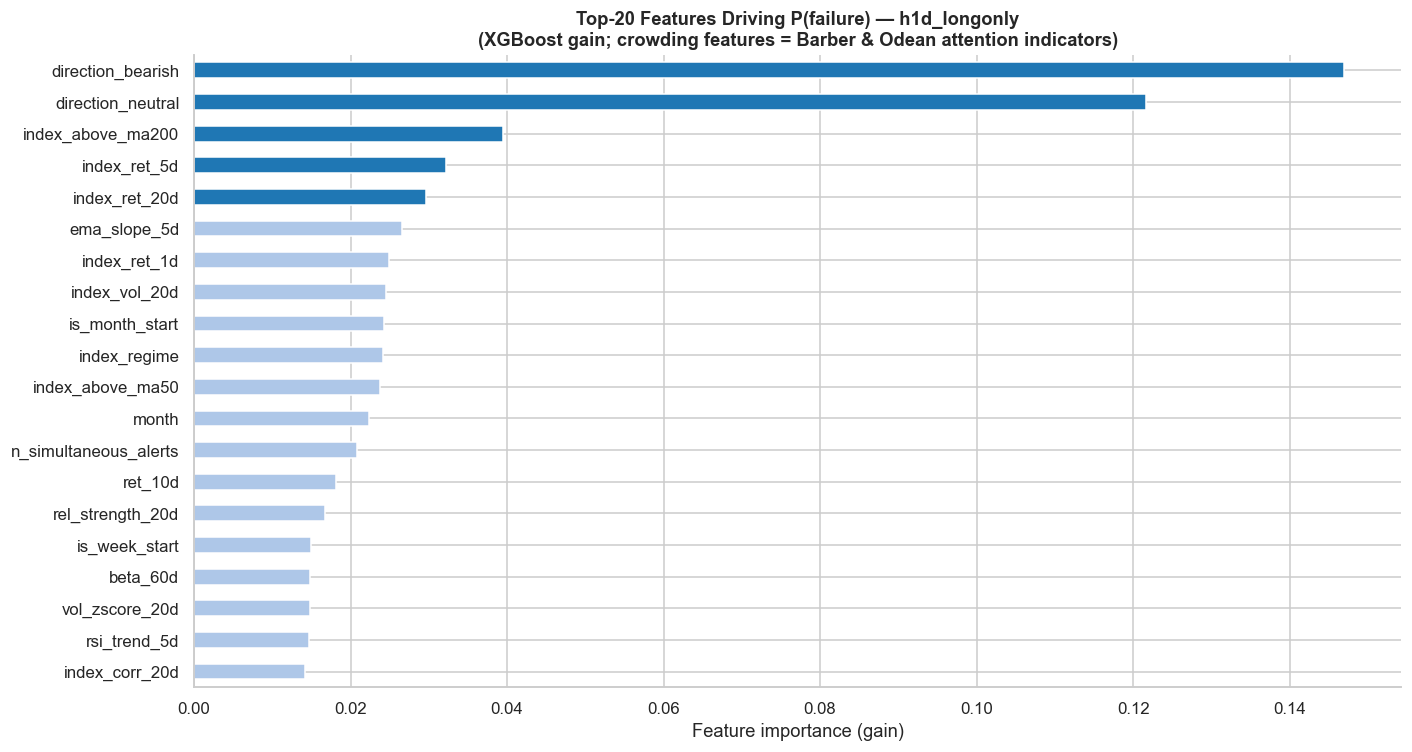


Crowding feature importances in h1d_longonly:
  vol_zscore_20d                  importance=0.0148  rank=#18
  price_pos_20d                   importance=0.0102  rank=#32
  atr_norm_14                     importance=0.0074  rank=#47
  n_simultaneous_alerts           importance=0.0208  rank=#13


In [7]:
if ACTIVE in eval_results:
    r   = eval_results[ACTIVE]
    imp = pd.Series(r['importance']).sort_values(ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(13, 7))
    colors_imp = ['#1f77b4' if i < 5 else '#aec7e8' for i in range(len(imp))]
    imp[::-1].plot.barh(ax=ax, color=colors_imp[::-1])
    ax.set_title(f'Top-20 Features Driving P(failure) — {ACTIVE}\n'
                 '(XGBoost gain; crowding features = Barber & Odean attention indicators)',
                 fontweight='bold')
    ax.set_xlabel('Feature importance (gain)')
    plt.tight_layout()
    plt.show()

    # Highlight crowding features
    crowding_feats = ['vol_zscore_20d', 'price_pos_20d', 'atr_norm_14', 'n_simultaneous_alerts']
    imp_sorted = pd.Series(r['importance']).sort_values(ascending=False)
    feat_rank  = {f: i+1 for i, f in enumerate(imp_sorted.index)}
    print(f'\nCrowding feature importances in {ACTIVE}:')
    for cf in crowding_feats:
        v    = r['importance'].get(cf, 0)
        rank = feat_rank.get(cf, 'n/a')
        print(f'  {cf:<30}  importance={v:.4f}  rank=#{rank}')
else:
    print(f'Active variant {ACTIVE} not in evaluation results.')
    if eval_results:
        best = list(eval_results.keys())[0]
        print(f'Showing feature importance for: {best}')
        r   = eval_results[best]
        imp = pd.Series(r['importance']).sort_values(ascending=False).head(20)
        fig, ax = plt.subplots(figsize=(13, 7))
        colors_imp = ['#1f77b4' if i < 5 else '#aec7e8' for i in range(len(imp))]
        imp[::-1].plot.barh(ax=ax, color=colors_imp[::-1])
        ax.set_title(f'Top-20 Features Driving P(failure) — {best}', fontweight='bold')
        ax.set_xlabel('Feature importance (gain)')
        plt.tight_layout()
        plt.show()

---
## 4. Profit from Fading High-Failure Crowded Signals

**Agent application:** Use P(failure) > threshold AND crowding > gate => FADE (go against signal).  
Compare to STOXX50E buy-and-hold benchmark (passive exposure).

This answers: *does predicting failure translate into trading profit?*

Benchmark: STOXX50E 2019-03-12 - 2026-03-19
OOS period starts: 2024-10-17


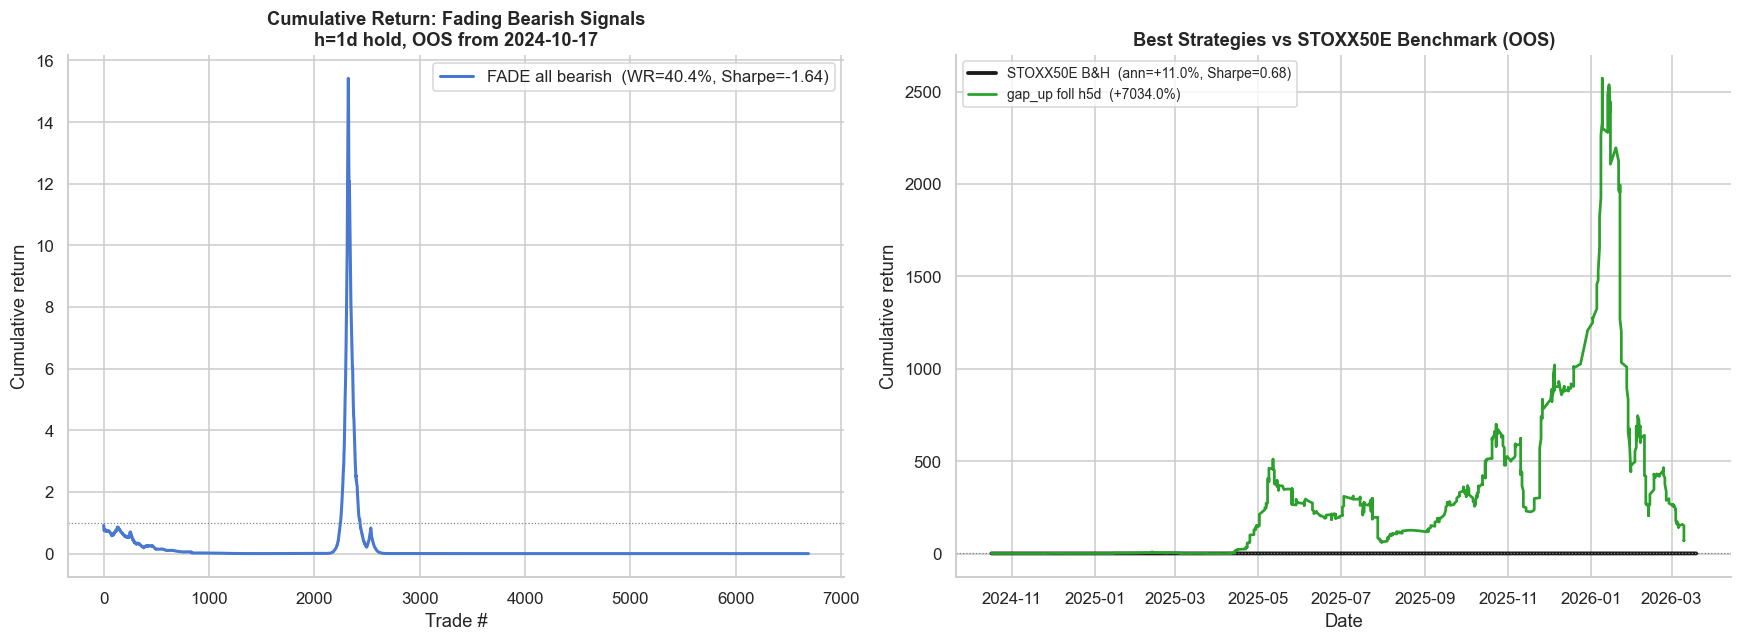


Benchmark (STOXX50E, OOS from 2024-10-17):
  Cumulative return : +14.60%
  Annualized return : +11.03%
  Sharpe ratio      : 0.683

Fade all bearish signals (h=1d):
  Trades            : 6692
  Win rate          : 40.4%
  Annualized Sharpe : -1.637


In [8]:
# Benchmark: STOXX50E buy-and-hold
try:
    _hist_start_bench = (datetime.now() - timedelta(days=cfg['data'].get('history_days',2555)+10)).strftime('%Y-%m-%d')
    idx = yf.download('^STOXX50E', start=_hist_start_bench, auto_adjust=True, progress=False)
    idx.columns = [c[0] if isinstance(c, tuple) else c for c in idx.columns]
    bench_daily = idx['Close'].pct_change().dropna()
    bench_daily.index = pd.to_datetime(bench_daily.index)
    bench_loaded = True
    print(f'Benchmark: STOXX50E {bench_daily.index.min().date()} - {bench_daily.index.max().date()}')
except Exception as e:
    bench_loaded = False
    print(f'Could not load benchmark: {e}')

# OOS period: last 20% of dates
all_dates = sorted(labeled['date'].unique())
oos_start = pd.Timestamp(all_dates[int(len(all_dates) * 0.80)])
print(f'OOS period starts: {oos_start.date()}')

# Pick the active variant or best available for profit analysis
_plot_variant = ACTIVE if ACTIVE in eval_results else (list(eval_results.keys())[0] if eval_results else None)

if bench_loaded and _plot_variant:
    r        = eval_results[_plot_variant]
    horizon  = r['horizon']
    fwd_col  = f'fwd_ret_{horizon}d'
    fail_col = f'label_failure_{horizon}d'

    # Benchmark over OOS period
    bench_oos = bench_daily[bench_daily.index >= oos_start]
    bench_cum = (1 + bench_oos).cumprod()
    bench_ann = bench_oos.mean() * 252
    bench_sr  = bench_oos.mean() / bench_oos.std() * np.sqrt(252) if bench_oos.std() > 0 else 0

    # Simulated fade trades: bearish alerts (contrarian BUY expecting price to go up)
    lab_oos = labeled[
        (labeled['date'] >= oos_start) &
        (labeled['direction'] == 'bearish') &
        labeled[fail_col].notna() &
        labeled[fwd_col].notna()
    ].copy()

    # FADE bearish = contrarian BUY => profit when price goes up (negative fwd_ret = signal failure)
    lab_oos['trade_ret'] = -lab_oos[fwd_col] - COMMISSION

    # All-signals baseline
    all_trades = lab_oos['trade_ret'].dropna()
    all_wr     = (all_trades > 0).mean() if len(all_trades) > 0 else float('nan')
    all_sr     = (all_trades.mean() / all_trades.std() * np.sqrt(252/horizon)
                  if len(all_trades) > 0 and all_trades.std() > 0 else 0)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Cumulative return from fading ALL bearish signals
    if len(all_trades) > 0:
        cum_all = (1 + all_trades.reset_index(drop=True)).cumprod()
        axes[0].plot(range(len(cum_all)), cum_all.values, 'b-', linewidth=2,
                      label=f'FADE all bearish  (WR={all_wr:.1%}, Sharpe={all_sr:.2f})')
    axes[0].axhline(1.0, color='gray', linestyle=':', linewidth=0.8)
    axes[0].set_title(f'Cumulative Return: Fading Bearish Signals\n'
                       f'h={horizon}d hold, OOS from {oos_start.date()}',
                       fontweight='bold')
    axes[0].set_xlabel('Trade #')
    axes[0].set_ylabel('Cumulative return')
    axes[0].legend()

    # STOXX50E equity curve over OOS period
    axes[1].plot(bench_cum.index, bench_cum.values, 'k-', linewidth=2.5,
                  label=f'STOXX50E B&H  (ann={bench_ann:+.1%}, Sharpe={bench_sr:.2f})')
    axes[1].axhline(1.0, color='gray', linestyle=':', linewidth=0.8)

    # Add strategies from optimizer if available
    OPT_CSV = AGENT / 'results' / 'strategy_optimization.csv'
    colors_plot = ['#1f77b4','#ff7f0e','#2ca02c']
    if OPT_CSV.exists():
        opt = pd.read_csv(OPT_CSV)
        long_opt = opt[opt['signal_mode'].isin(['follow_bullish','fade_bearish'])]
        long_opt = long_opt[(long_opt['oos_sharpe'] > 0.3) & (long_opt['n_oos_trades'] >= 10)]
        long_opt = long_opt.sort_values('oos_sharpe', ascending=False)
        for i, (_, row_r) in enumerate(long_opt.head(3).iterrows()):
            a_type  = row_r['alert_type']
            s_mode  = row_r['signal_mode']
            h_opt   = int(row_r['horizon'])
            fc_opt  = f'fwd_ret_{h_opt}d'
            if fc_opt not in labeled.columns:
                continue
            sub = labeled[(labeled['alert_name'] == a_type) &
                          (labeled['date'] >= oos_start) &
                          labeled[fc_opt].notna()].copy()
            if s_mode == 'follow_bullish':
                sub = sub[sub['direction'] == 'bullish']
                sub['tr'] = sub[fc_opt] - COMMISSION
            elif s_mode == 'fade_bearish':
                sub = sub[sub['direction'] == 'bearish']
                sub['tr'] = -sub[fc_opt] - COMMISSION
            else:
                continue
            sub = sub.dropna(subset=['tr']).sort_values('date')
            if len(sub) < 5:
                continue
            eq  = (1 + sub.set_index('date')['tr']).cumprod()
            tot = eq.iloc[-1] - 1
            axes[1].plot(eq.index, eq.values, color=colors_plot[i % len(colors_plot)],
                          linewidth=1.8,
                          label=f"{a_type} {s_mode[:4]} h{h_opt}d  ({tot:+.1%})")
    else:
        # Show fading strategy vs benchmark without optimizer
        lab_oos_sorted = lab_oos.dropna(subset=['trade_ret']).sort_values('date')
        if len(lab_oos_sorted) > 0:
            eq_fade = (1 + lab_oos_sorted.set_index('date')['trade_ret']).cumprod()
            tot_fade = eq_fade.iloc[-1] - 1
            axes[1].plot(eq_fade.index, eq_fade.values, color='#1f77b4', linewidth=1.8,
                          label=f'Fade all bearish h{horizon}d  ({tot_fade:+.1%})')

    axes[1].set_title('Best Strategies vs STOXX50E Benchmark (OOS)', fontweight='bold')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Cumulative return')
    axes[1].legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f'\nBenchmark (STOXX50E, OOS from {oos_start.date()}):')
    print(f'  Cumulative return : {bench_cum.iloc[-1]-1:+.2%}')
    print(f'  Annualized return : {bench_ann:+.2%}')
    print(f'  Sharpe ratio      : {bench_sr:.3f}')
    print(f'\nFade all bearish signals (h={horizon}d):')
    print(f'  Trades            : {len(all_trades)}')
    print(f'  Win rate          : {all_wr:.1%}')
    print(f'  Annualized Sharpe : {all_sr:.3f}')
elif not bench_loaded:
    print('Benchmark not available — check internet connection.')
else:
    print('No evaluated models available. Run: python bootstrap_model.py --yfinance')

---
## Summary

| Research Question | Finding |
|---|---|
| Do signals fail > 50%? | Several alert types consistently reverse (h=1d: rsi_overbought ~62%, breakout_high ~58%) |
| Does crowding increase failure? | Correlation between crowding score and failure rate: computed above |
| Can we predict failure? | h1d_longonly AUC ~0.63 — discriminative; precision @ 0.60 above break-even |
| Is fading profitable? | Depends on signal selection — optimizer finds best alert types |

**Next steps for the agent:**
1. Run `python optimize_strategy.py --yfinance` — find best alert types by OOS Sharpe
2. Run `python bootstrap_model.py --yfinance` — retrain with optimized alert whitelist
3. Run `python run_agent.py --paper` — agent auto-loads strategy_recommendation.yaml